### Import statements, load data, and restructure DataFrames for analaysis
Loads data already processed at the population-level (see population_processing.ipynb) and sets some helpful parameters. 

In [4]:
import mne
import numpy as np
import pandas as pd

# Define some parameters
analysis_params = {
        'win_dur': 0.2,
        'win_step': 0.05, 
        'tmin_plot': -1.0, 
        'tmax_plot': 2.3
    }

# Load some sample data to get data object information
subject = 'S25_245'
fn_prefix = f'../../derivatives/pulse_labels/{subject}'
epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
epochs_trigger = epochs_trigger.crop(tmin=-1, tmax=2.3) 

# Define the windows used for analysis
tfr_times = epochs_trigger.times
win_starts = np.arange(analysis_params['tmin_plot'], analysis_params['tmax_plot'] - analysis_params['win_dur'], analysis_params['win_step'])
win_centers = win_starts + (analysis_params['win_dur'] / 2)

# Load processed DataFrame - the result of population_processing.ipynb
hfa = pd.read_pickle('../outputs/iTBS_multitaper_HFA_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')
hfaSham = pd.read_pickle('../outputs/iTBS_multitaper_ShamHFA_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')
theta = pd.read_pickle('../outputs/iTBS_multitaper_theta_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')
thetaSham = pd.read_pickle('../outputs/iTBS_multitaper_Shamtheta_onlyHigh_0.2dur_0.05step_outliersExcluded.pkl')

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/4213637018.py:16: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/4213637018.py:16: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs_trigger = mne.read_epochs(f"{fn_prefix}_trigs-epo.fif", verbose=False)


Rename subject IDs for those who have more than one stimulation site (appending "_a", "_b", etc.)

In [5]:
import string

# 1. Define helper list and concatenate
dfs_to_join = [
    (hfa, 'HFA', 'active'),
    (hfaSham, 'HFA', 'sham'),
    (theta, 'theta', 'active'),
    (thetaSham, 'theta', 'sham')
]

for df, freq, cond in dfs_to_join:
    df['frequency'] = freq
    df['activeVsSham'] = cond

df_joint = pd.concat([hfa, hfaSham, theta, thetaSham], ignore_index=True)

# --- Re-assign Subject IDs based on Target ---

# 2. Identify unique Subject-Target pairs
# We sort them to ensure suffix assignment is consistent (e.g., Target A is always 'a')
pairs = df_joint[['subject', 'target']].drop_duplicates().sort_values(['subject', 'target'])

# 3. Create a suffix for subjects with multiple targets
# cumcount() gives 0 for the first target, 1 for the second, etc.
letters = list(string.ascii_lowercase)
pairs['suffix'] = pairs.groupby('subject').cumcount().map(lambda x: f"_{letters[x]}" if x < 26 else f"_{x}")

# 4. Create the new unique subject ID
pairs['new_subject_id'] = pairs['subject'].astype(str) + pairs['suffix']

# 5. Merge the new IDs back into the master DataFrame
df_joint = df_joint.merge(
    pairs[['subject', 'target', 'new_subject_id']], 
    on=['subject', 'target'], 
    how='left'
)

# 6. Swap the old subject column for the new one and clean up
df_joint['original_subject'] = df_joint['subject'] # Keep a backup just in case
df_joint['subject'] = df_joint['new_subject_id']
df_joint.drop(columns=['new_subject_id'], inplace=True)

# --- FINALIZE VIEW ---

# 7. Move columns to the front
cols = ['subject', 'target', 'frequency', 'activeVsSham'] + \
       [c for c in df_joint.columns if c not in ['subject', 'target', 'frequency', 'activeVsSham']]
df_joint = df_joint[cols]

print(f"Joint DataFrame created with {len(df_joint)} rows.")
print(f"Unique subject-target entities: {df_joint['subject'].nunique()}")

Joint DataFrame created with 36408 rows.
Unique subject-target entities: 26


#### Define plotting functions

In [6]:
import pylab as plt
import seaborn as sns
from scipy.stats import pearsonr

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

def plot_pre_post_power_blocks_windowed(df, time_vector, time_window=None, ylim_=(-0.04, 0.04), fname=None):
    """
    Plots Pre vs Post power across blocks with solid intra-block connectors 
    and dashed inter-block connectors.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from scipy.stats import sem

    # 1. Define Order
    block_order = [
        ('iTBS1', 'active'), ('iTBS1', 'sham'),
        ('iTBS2', 'active'), ('iTBS2', 'sham'),
        ('iTBS3', 'active'), ('iTBS3', 'sham')
    ]
    plot_labels = [f"{b}\n{c.capitalize()}" for b, c in block_order]
    
    # 2. Setup Time Mask
    if time_window is not None:
        t_mask = (time_vector >= time_window[0]) & (time_vector <= time_window[1])
    else:
        t_mask = np.ones(len(time_vector), dtype=bool)

    means_pre, sems_pre = [], []
    means_post, sems_post = [], []

    for block, cond in block_order:
        mask = (df['block'] == block) & (df['activeVsSham'] == cond)
        subset = df[mask].copy()
        
        if subset.empty:
            for l in [means_pre, sems_pre, means_post, sems_post]: l.append(np.nan)
            continue

        def get_windowed_mean(val):
            if isinstance(val, np.ndarray):
                windowed_data = val[:, t_mask] if val.ndim == 2 else val[t_mask]
                return np.nanmean(windowed_data)
            return val

        subset['pre_scalar'] = subset['pre_tfr'].apply(get_windowed_mean)
        subset['post_scalar'] = subset['post_tfr'].apply(get_windowed_mean)

        sub_level = subset.groupby(['subject', 'target'])[['pre_scalar', 'post_scalar']].mean().reset_index()

        means_pre.append(sub_level['pre_scalar'].mean())
        sems_pre.append(sem(sub_level['pre_scalar'], nan_policy='omit'))
        means_post.append(sub_level['post_scalar'].mean())
        sems_post.append(sem(sub_level['post_scalar'], nan_policy='omit'))

    # 6. Plotting
    x = np.arange(len(block_order))
    fig, ax = plt.subplots(figsize=(9, 2.7))

    # --- ADDED: Connecting Lines ---
    for i in range(len(x)):
        # Solid line between Pre and Post within the SAME block
        ax.plot([x[i] - 0.15, x[i] + 0.15], [means_pre[i], means_post[i]], 
                color='k', linestyle='-', linewidth=1.5, alpha=0.9, zorder=1)
        
        # Dashed line between Post of block i and Pre of block i+1
        if i < len(x) - 1:
            ax.plot([x[i] + 0.15, x[i+1] - 0.15], [means_post[i], means_pre[i+1]], 
                    color='k', linestyle='--', linewidth=1, alpha=0.9, zorder=1)

    # Plot the data points (zorder=2 ensures points are on top of lines)
    ax.errorbar(x - 0.15, means_pre, yerr=sems_pre, fmt='o', capsize=3, 
                label='Pre-TBS', color='#7f8c8d', markersize=9, elinewidth=2, zorder=2)
    
    ax.errorbar(x + 0.15, means_post, yerr=sems_post, fmt='s', capsize=3, 
                label='Post-TBS', color='#c0392b', markersize=9, elinewidth=2, zorder=2)

    # Universal Formatting
    ax.set_xticks(x)
    ax.set_xticklabels(plot_labels)
    ax.set_ylabel('Mean Power (z-score)')
    
    win_str = f"{time_window}s" if time_window else "Full Epoch"
    ax.set_title(f'Power Evolution Across Blocks | Window: {win_str}', fontweight='bold', fontsize=14)
    
    ax.grid(True, axis='y', linestyle=':', alpha=0.6)
    ax.axhline(y=0, color='k',)
    ax.legend(frameon=True, loc='best')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    if ylim_ is not None:
        ax.set_ylim(ylim_)

    plt.tight_layout()
    if fname:
        plt.savefig(fname)
    plt.show()


def plot_block_correlations_single_subject(df, subject_id, win_centers, time_window, cols_per_row=3):
    # 1. Data Prep: Filter for single subject and calculate windowed mean
    df = df[df['subject'] == subject_id].copy()
    if df.empty:
        print(f"No data found for subject: {subject_id}")
        return

    # Calculate mean t-stat in window
    t_start, t_end = time_window
    t_mask = (win_centers >= t_start) & (win_centers <= t_end)
    df['mean_window_t'] = [np.nanmean(ts[t_mask]) for ts in df['t_stats'].values]
    
    # NEW: Create a unique identifier combining block and condition
    # This forces Active iTBS1 and Sham iTBS1 into separate panels
    df['block_type'] = df['block'] + " (" + df['activeVsSham'] + ")"
    
    # Get unique subtypes (sorted ensures iTBS1 Active/Sham stay together)
    subtypes = sorted(df['block_type'].unique())
    n_panels = len(subtypes)
    n_rows = (n_panels + cols_per_row - 1) // cols_per_row
    
    # 2. Setup Figure
    fig, axes = plt.subplots(n_rows, cols_per_row, 
                             figsize=(4 * cols_per_row, 4 * n_rows), 
                             sharex=True, sharey=True)
    
    if n_panels == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # Using a slightly different palette to distinguish the more numerous panels
    palette = sns.color_palette("husl", n_panels)
    
    # 3. Iterate through the unique Block + Condition combinations
    for i, b_type in enumerate(subtypes):
        ax = axes[i]
        
        # Filter for this specific combination
        panel_df = df[df['block_type'] == b_type].dropna(subset=['mean_window_t', 'ptp'])
        
        if len(panel_df) > 2:
            # Calculate stats
            r, p = pearsonr(panel_df['mean_window_t'], panel_df['ptp'])
            
            # Plot
            sns.regplot(data=panel_df, x='mean_window_t', y='ptp', 
                        ax=ax, color=palette[i], scatter_kws={'alpha':0.6},
                        line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 1})
            
            # Annotate Subplot
            ax.set_title(b_type, fontweight='bold')
            ax.text(0.05, 0.9, f'r={r:.2f}\np={p:.3f}', transform=ax.transAxes, 
                    fontsize=9, bbox=dict(facecolor='white', alpha=0.5))
        else:
            ax.text(0.5, 0.5, f'Insufficient Data\n(N={len(panel_df)})', ha='center')
            ax.set_title(b_type)

        ax.set_xlabel('HFA Change (t-stat)')
        ax.set_ylabel('PTP Amp (z-score)')

    # 4. Clean up Empty Subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    # Global Labels
    plt.suptitle(f'Subject {subject_id}: T-Stat vs. PTP Correlation (Active vs. Sham Split)\nWindow: {t_start}-{t_end}s', 
                 fontsize=15, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.show()

## Visualize power over experimental blocks
Plots average power in a specified subgroup for each spES block. 

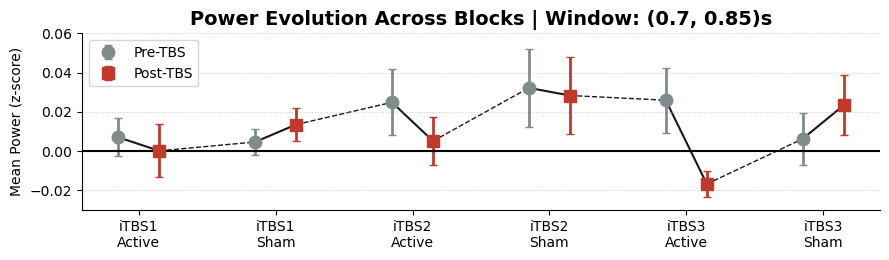

In [7]:
# For filtering out bad electrodes based on keywords
bad_elec_keywords = 'out|lesion|damage|empty|unknown' 

# Filter for deired channels/subjects
plot_subset_top = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['baseline_ptp']>10) &
                        (df_joint['activeVsSham'].str.contains(''))
                            ]

# Plot experimental timecourse
plot_pre_post_power_blocks_windowed(plot_subset_top, win_centers, time_window=(0.7, 0.85), ylim_=(-0.03, 0.06), fname=None)

**Select lowest-PTP channels as out-of-network**

In [8]:
# Helper function for this cell
def get_smallest_channels(df, col_name, N=5):
    def get_n(sub):
        return N[sub] if isinstance(N, dict) else N
        
    return df.assign(abs_val=df[col_name].abs()).groupby('subject', group_keys=False).apply(
        lambda g: g.nsmallest(get_n(g.name), 'abs_val')
    ).drop(columns=['abs_val'])

# Only need to look at first iTBS session to grab the unique in-network channels
plot_subset_top = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['block']=='iTBS1') &
                        (df_joint['baseline_ptp']>10) &
                        (df_joint['activeVsSham'].str.contains('active'))
                            ]

# Identify number of channels per subject
sub_ns = {k: v for d in [{s: len(plot_subset_top[plot_subset_top['subject']==s])} for s in plot_subset_top['subject'].unique()] for k, v in d.items()}

### Grab a list of lowest-responding channels matched to number of top channels ###

# First get a copy of the DataFrame just with the first iTBS session
plot_subset_bottom = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['block']=='iTBS1') &
                        (df_joint['activeVsSham'].str.contains('active'))
                            ]

plot_subset_bottom = get_smallest_channels(plot_subset_bottom[plot_subset_bottom['subject'].str.contains("|".join(map(str, sub_ns.keys())))], 'baseline_ptp', N=sub_ns)
df_pairs = plot_subset_bottom[['subject', 'channel']]

# Redefining plot_subset_bottom, this time with all iTBS sessions
plot_subset_bottom = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['activeVsSham'].str.contains(''))
                            ]

large_index = pd.MultiIndex.from_frame(plot_subset_bottom[['subject', 'channel']])
pairs_index = pd.MultiIndex.from_frame(df_pairs[['subject', 'channel']])
plot_subset_bottom = plot_subset_bottom[large_index.isin(pairs_index)]

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/2404263209.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.assign(abs_val=df[col_name].abs()).groupby('subject', group_keys=False).apply(


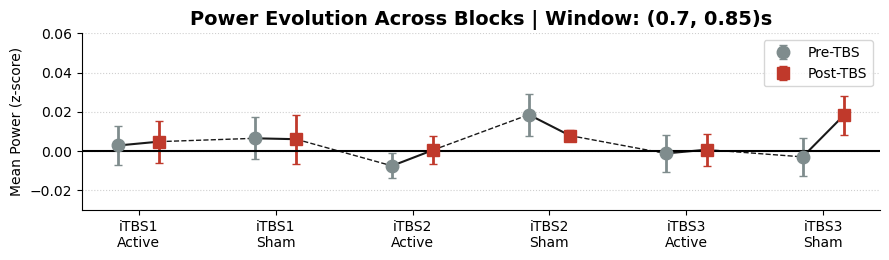

In [9]:
plot_pre_post_power_blocks_windowed(plot_subset_bottom, win_centers, time_window=(0.7, 0.85), ylim_=(-0.03, 0.06), fname=None)

### LMM analysis for overall effect of TBS

In [10]:
def safe_window_mean(arr, mask):
    """Safely computes nanmean or returns np.nan on error."""
    try:
        # Check if arr is indexable (handles cases where a cell might be None/NaN)
        if arr is None or not isinstance(arr, (np.ndarray, list)):
            return np.nan
        
        # Apply the mask
        sliced = arr[mask]
        
        # If the slice is empty, np.nanmean would warn; we return nan instead
        if len(sliced) == 0:
            return np.nan
            
        return np.nanmean(sliced)
    except Exception:
        return np.nan

def compute_windowed_metrics(df, win_centers, t_start, t_end):
    # 1. Create the mask
    mask = (win_centers >= t_start) & (win_centers <= t_end)
    window_label = f"[{t_start}, {t_end}]"
    
    # 2. Compute averages using the safe helper
    df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
    df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
    
    # 3. Metadata tracking
    df['stats_window_range'] = window_label
    
    # Report count of failures (NaNs)
    nan_count = df['window_mean_t'].isna().sum()
    print(f"Metrics computed for window: {window_label}")
    if nan_count > 0:
        print(f"⚠️ Warning: {nan_count} rows resulted in NaN (likely empty or invalid data).")
        
    return df

**Test for overall effect of TBS across blocks**

In [32]:
from patsy.contrasts import Sum
import statsmodels.formula.api as smf

use_out_of_network = False

# Define subgroup for analysis (note this subgroup will carry forward to subsequent cells)
plot_subset = df_joint[
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['block'].str.contains('')) &
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['baseline_ptp']>10) &
                        (df_joint['activeVsSham'].str.contains('active'))
                            ]

# Can switch to analyzing plot_subset_bottom if needed
if use_out_of_network==True:
    plot_subset = plot_subset_bottom[plot_subset_bottom['block'].str.contains('') &
                                    plot_subset_bottom['activeVsSham'].str.contains('active')]

# Get averaged t-stats in desired window
t_start, t_end = 0.7, 0.85
plot_subset_win = compute_windowed_metrics(plot_subset, win_centers, t_start, t_end)

# Whether or not to average first across blocks -- a good sanity check for the validity of the mixed effects model output
use_block_avg = False

# 1. Clean data
df_lme = plot_subset_win.copy()
df_lme = df_lme.dropna(subset=['window_mean_t']).copy()
df_lme['subject_channel'] = df_lme['subject'].astype(str) + "_" + df_lme['channel'].astype(str)

# If averaging across blocks first, block is not included as a factor in the model
df_block_avg = df_lme.groupby(['subject', 'channel', 'activeVsSham'])['window_mean_t'].mean().reset_index()

# 2. Define the Model
if use_block_avg:

    # Average first across all iTBS blocks, then define subject as random effect.
    # No need to define block as fixed effect, already averaged out. 

    formula = "window_mean_t ~ 1 "

    # 3. Fit the Model
    # Each 'subject' is a group; blocks and channels are observations within that group.
    model = smf.mixedlm(formula, df_block_avg, groups=df_block_avg["subject"],
                       )
    result = model.fit(reml=True)

else:

    # Fit model accounting for effect of each block, using Sum coding to interpret intercept as grand-average effect. 
    formula = "window_mean_t ~ C(block, Sum)"

    # 3. Fit the Model
    # Each 'subject' is a group; blocks and channels are observations within that group.
    model = smf.mixedlm(formula, df_lme,
                    groups=df_lme["subject"],
                       )
    result = model.fit(reml=True)

# 4. Output
print("\n" + "="*60)
print("TARGET-LEVEL REPEATED MEASURES LME")
print(f"Total Observations: {len(df_lme)}")
print(f"Unique Sites (Groups): {df_lme['subject'].nunique()}")
print("="*60)
print(result.summary())

# Also test with standard t-test for comparison or optimization failure (another good sanity check)
from scipy.stats import ttest_1samp
print("\n" + "="*60)
print("1-sample T-test Measure")
print(ttest_1samp(df_lme.groupby('subject')['window_mean_t'].mean(), 0))

Metrics computed for window: [0.7, 0.85]

TARGET-LEVEL REPEATED MEASURES LME
Total Observations: 197
Unique Sites (Groups): 12
              Mixed Linear Model Regression Results
Model:              MixedLM   Dependent Variable:   window_mean_t
No. Observations:   197       Method:               REML         
No. Groups:         12        Scale:                1.0623       
Min. group size:    1         Log-Likelihood:       -291.6981    
Max. group size:    71        Converged:            Yes          
Mean group size:    16.4                                         
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.391    0.140 -2.786 0.005 -0.665 -0.116
C(block, Sum)[S.iTBS1]  0.113    0.104  1.088 0.277 -0.091  0.317
C(block, Sum)[S.iTBS2] -0.104    0.106 -0.984 0.325 -0.311  0.103
Group Var               0.083

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

**Test for in-network vs out-of-network difference, active vs. sham difference in a combined model**

In [33]:
plot_subset_t = df_joint[
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['block'].str.contains('')) &
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['baseline_ptp']>10) &
                        (df_joint['activeVsSham'].str.contains(''))
                            ]

plot_subset_b = plot_subset_bottom[plot_subset_bottom['block'].str.contains('') &
                                plot_subset_bottom['activeVsSham'].str.contains('')]


# 1. Add the designation column to copies of each DataFrame
df_top = plot_subset_t.assign(designation='top')
df_bottom = plot_subset_b.assign(designation='bottom')

# 2. Concatenate them row-wise into a single DataFrame
plot_subset_combined = pd.concat([df_top, df_bottom], ignore_index=True)

# Get windowed data
t_start, t_end = 0.7, 0.85
plot_subset_combined = compute_windowed_metrics(plot_subset_combined, win_centers, t_start, t_end)

formula = "window_mean_t ~ C(block) + C(designation, Treatment('bottom')) + C(activeVsSham, Treatment('sham'))"

# 3. Fit the Model
# Each 'subject' is a group; blocks and channels are observations within that group.
model = smf.mixedlm(formula, plot_subset_combined,
                groups=plot_subset_combined["subject"],
                   )
result = model.fit(reml=True)
print(result.summary())

Metrics computed for window: [0.7, 0.85]
                         Mixed Linear Model Regression Results
Model:                      MixedLM          Dependent Variable:          window_mean_t
No. Observations:           767              Method:                      REML         
No. Groups:                 12               Scale:                       1.0519       
Min. group size:            4                Log-Likelihood:              -1117.2570   
Max. group size:            278              Converged:                   Yes          
Mean group size:            63.9                                                       
---------------------------------------------------------------------------------------
                                             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------
Intercept                                     0.311    0.098  3.170 0.002  0.119  0.503
C(block)[T.iTBS2

**Test sensitivity to CCEP cutoff threshold (Supplement)**

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

Metrics computed for window: [0.7, 0.85]
Metrics computed for window: [0.7, 0.85]
Metrics computed for window: [0.7, 0.85]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

Metrics computed for window: [0.7, 0.85]
Metrics computed for window: [0.7, 0.85]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

Metrics computed for window: [0.7, 0.85]
Metrics computed for window: [0.7, 0.85]
Metrics computed for window: [0.7, 0.85]
Metrics computed for window: [0.7, 0.85]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

Metrics computed for window: [0.7, 0.85]


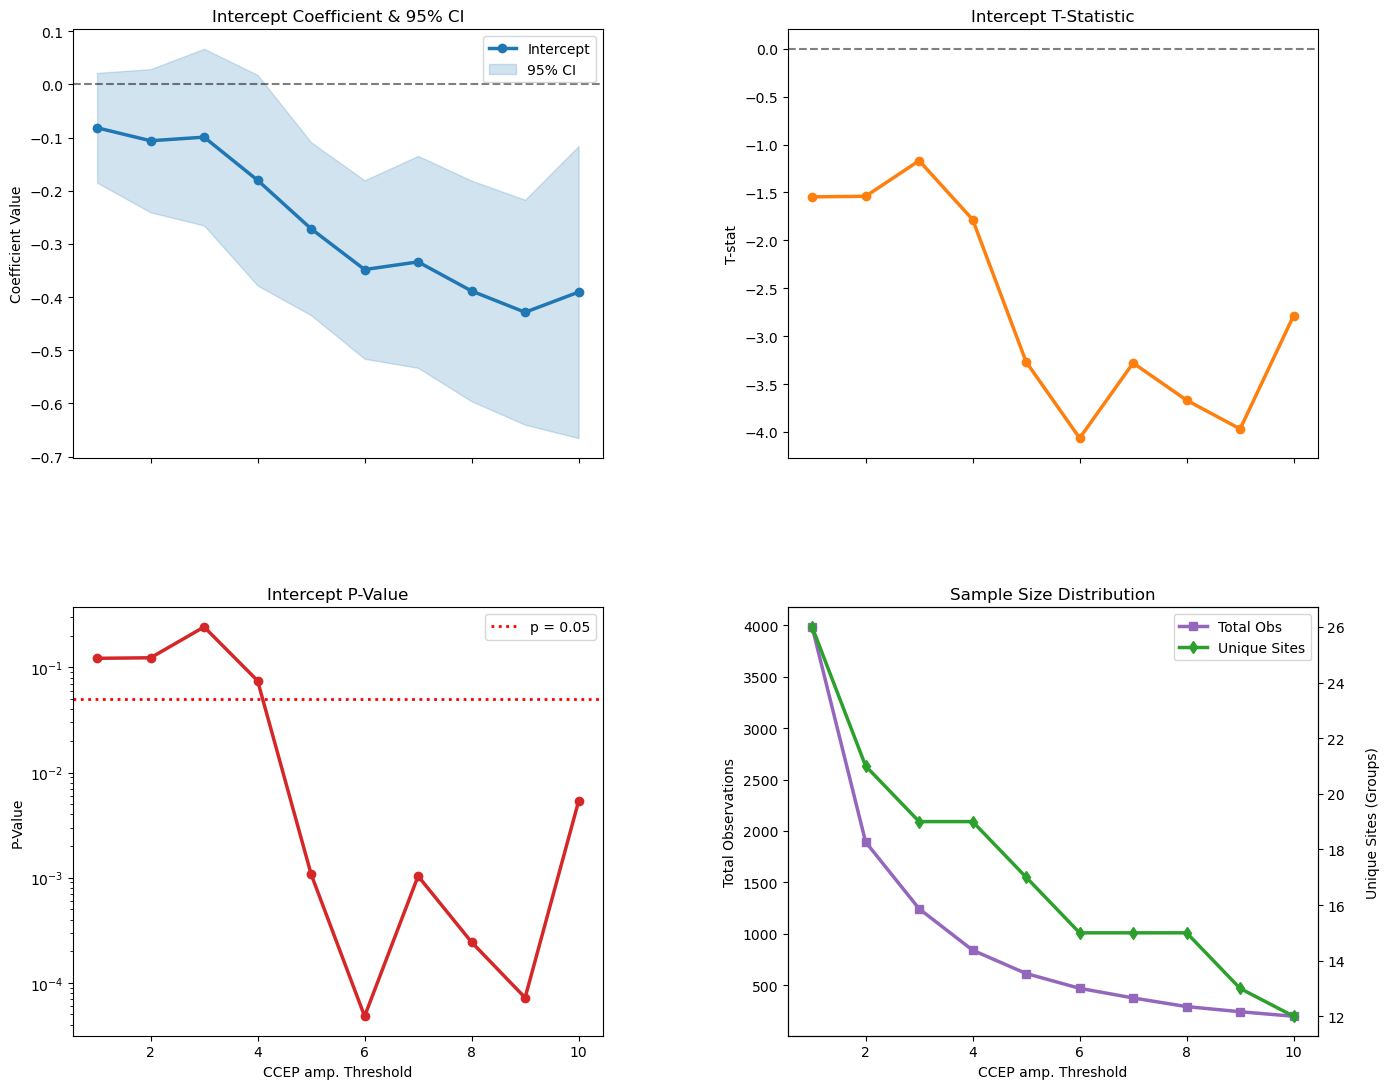

In [27]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

# --- Set Global Font Sizes (Increased by ~25%) ---

# Initialize lists to store metrics across thresholds
thresholds = list(range(1, 11))
coefs = []
z_stats = []
p_values = []
ci_lowers = []
ci_uppers = []
n_observations = []
n_groups = []

t_start, t_end = 0.7, 0.85
formula = "window_mean_t ~ C(block, Sum)"

# Loop through thresholds
for thres in thresholds:
    # 1. Filter subset using current threshold
    plot_subset = df_joint[
        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
        (df_joint['subject'].str.contains('')) & 
        (df_joint['frequency'] == 'HFA') & 
        (df_joint['block'].str.contains('')) &
        (df_joint['is_bad'] == False) &
        (df_joint['is_lead'] == False) &
        (df_joint['baseline_ptp'] > thres) &  
        (df_joint['activeVsSham'].str.contains('active'))
    ]
    
    # 2. Compute windowed metrics
    plot_subset = compute_windowed_metrics(plot_subset, win_centers, t_start, t_end)
    
    # 3. Clean data
    df_lme = plot_subset.dropna(subset=['window_mean_t']).copy()
    
    if len(df_lme) == 0 or df_lme['subject'].nunique() < 2:
        for lst in [coefs, z_stats, p_values, ci_lowers, ci_uppers, n_observations, n_groups]:
            lst.append(np.nan)
        continue
        
    # 4. Fit the Model
    try:
        model = smf.mixedlm(formula, df_lme, groups=df_lme["subject"])
        result = model.fit(method=None)
        
        # 5. Extract Intercept Metrics
        coefs.append(result.params['Intercept'])
        z_stats.append(result.tvalues['Intercept'])
        p_values.append(result.pvalues['Intercept'])
        
        ci = result.conf_int().loc['Intercept']
        ci_lowers.append(ci[0])
        ci_uppers.append(ci[1])
        
        n_observations.append(len(df_lme))
        n_groups.append(df_lme['subject'].nunique())
        
    except Exception as e:
        print(f"Model fitting failed at threshold {thres}: {e}")
        for lst in [coefs, z_stats, p_values, ci_lowers, ci_uppers, n_observations, n_groups]:
            lst.append(np.nan)

# Convert to arrays to facilitate math/plotting safely with NaNs
thresholds = np.array(thresholds)
coefs = np.array(coefs)
ci_lowers = np.array(ci_lowers)
ci_uppers = np.array(ci_uppers)

# --- Plotting the Sensitivity Analysis Results ---
fig, axes = plt.subplots(2, 2, figsize=(14, 11), sharex=True)
axes = axes.flatten()

# Plot 1: Coefficient with Filled 95% CI
axes[0].plot(thresholds, coefs, '-o', color='tab:blue', lw=2.5, label='Intercept')
axes[0].fill_between(thresholds, ci_lowers, ci_uppers, color='tab:blue', alpha=0.2, label='95% CI')
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Intercept Coefficient & 95% CI')
axes[0].set_ylabel('Coefficient Value')
axes[0].legend(loc='best')

# Plot 2: Z-statistic
axes[1].plot(thresholds, z_stats, '-o', color='tab:orange', lw=2.5)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Intercept T-Statistic')
axes[1].set_ylabel('T-stat')

# Plot 3: P-value
axes[2].plot(thresholds, p_values, '-o', color='tab:red', lw=2.5)
axes[2].axhline(0.05, color='red', linestyle=':', lw=2, label='p = 0.05')
axes[2].set_title('Intercept P-Value')
axes[2].set_ylabel('P-Value')
axes[2].set_yscale('log')
axes[2].legend(loc='best')

# Plot 4: Sample Size Distribution
ax4_twin = axes[3].twinx()
p1 = axes[3].plot(thresholds, n_observations, '-s', color='tab:purple', label='Total Obs', lw=2.5)
p2 = ax4_twin.plot(thresholds, n_groups, '-d', color='tab:green', label='Unique Sites', lw=2.5)
axes[3].set_title('Sample Size Distribution')
axes[3].set_ylabel('Total Observations')
ax4_twin.set_ylabel('Unique Sites (Groups)', labelpad=15)

# Merge legends for the twin axis plot
lns = p1 + p2
labs = [l.get_label() for l in lns]
axes[3].legend(lns, labs, loc='best')

# Clean up layout, remove grids, adjust vertical spacing
for ax in axes:
    ax.grid(False) # Turn off gridlines
    
ax4_twin.grid(False) # Explicitly turn off grid for twin axis too

# Shared X axis label
for ax in axes[2:]:
    ax.set_xlabel('CCEP amp. Threshold')

# tight_layout with explicit hspace control to increase whitespace between rows
plt.tight_layout()
fig.subplots_adjust(hspace=0.35, wspace=0.35) 
#plt.savefig('./figs/supplemental_threshold_Intercept.pdf')
plt.show()

#### Visualize hierarchical data
Rainplots to visualize the distribution of effects across channels and subjects

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/593626784.py:23: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=df_collapsed, x='block', y='window_mean_t', hue='subject',
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/593626784.py:28: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=df_collapsed, x='block', y='window_mean_t',


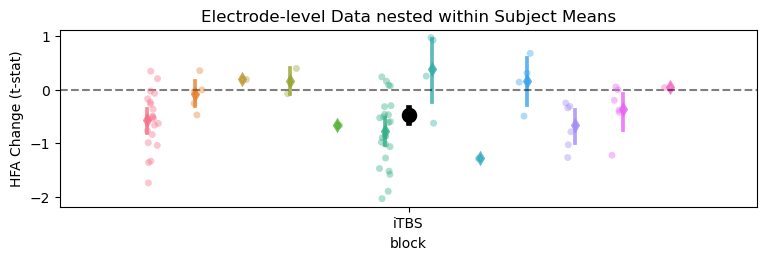

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 2.3))

# Group by Subject and Electrode (assuming 'electrode' is your column name)
# This averages the t-stats across the 3 blocks for each specific site
df_collapsed = plot_subset_win.groupby(['subject', 'channel']).agg({
    'window_mean_t': 'mean',
    # Include other columns you want to keep
    'baseline_ptp': 'mean' 
}).reset_index()

# Assign the new block label
df_collapsed['block'] = 'iTBS'

# 1. Plot every single electrode as a tiny dot (transparency is key)
sns.stripplot(data=df_collapsed, x='block', y='window_mean_t', hue='subject', 
              dodge=True, alpha=0.4, palette='husl', size=5, legend=False)

# 2. Overlay a Boxplot or Pointplot for the Subject-level averages
# This shows the variance the model is actually working with
sns.pointplot(data=df_collapsed, x='block', y='window_mean_t', hue='subject', 
              dodge=0.75, markers='d', scale=1.0, linestyles='--', alpha=0.8, palette='husl',
             legend=False)

# 3. Add the "Grand Mean" (The Fixed Effect from your LME)
sns.pointplot(data=df_collapsed, x='block', y='window_mean_t', 
              color='black', markers='o', scale=1.5, label='Fixed Effect (Grand Mean)',
             legend=False)

plt.title("Electrode-level Data nested within Subject Means")
plt.ylabel("HFA Change (t-stat)")
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
#plt.savefig('./figs/rainplots_zscore10.pdf')
plt.show()

#### Fit models to estimate effect at each post-pulse latency (then FDR correct for multiple comparisons)
Model convergence failures are replaced with output of 1-sample t-test (these do not occur during principal time window of interest)

In [35]:
import warnings
from scipy.stats import ttest_1samp
import numpy as np
from statsmodels.tools.sm_exceptions import ConvergenceWarning
# import statsmodels.formula.api as smf 

# --- Toggle to average across blocks ---
use_block_avg = False

# Vectors for the main results (LME with fallback)
pvals = []
zvals = []
fallback_flag = []

# Vectors strictly for the 1-sample t-test results (computed every loop)
ttest_pvals = []
ttest_tvals = []

# Loop through time windows from -500ms to +2 seconds
time_starts = np.arange(-0.5, 2.01, 0.05)
for t_start in time_starts:

    # Compute t-statistics averaged within windows
    plot_subset_win = compute_windowed_metrics(plot_subset, win_centers, t_start, t_start+0.2)

    # 1. Clean data
    df_lme = plot_subset_win.copy()
    df_lme = df_lme.dropna(subset=['window_mean_t']).copy()
    df_lme['subject_channel'] = df_lme['subject'].astype(str) + "_" + df_lme['channel'].astype(str)

    # --- NEW: Always compute the 1-sample t-test and store the results ---
    # Calculate subject-level means for the t-test
    subject_means = df_lme.groupby('subject')['window_mean_t'].mean()
    t_stat, p_val = ttest_1samp(subject_means, 0)
    
    # Aggregate into output vectors
    ttest_tvals.append(t_stat)
    ttest_pvals.append(p_val)

    # --- Apply block averaging if toggled ---
    if use_block_avg:
        # Group by subject and channel to collapse the block dimension
        df_lme = df_lme.groupby(
            ['subject', 'channel', 'subject_channel'], as_index=False
        )[['window_mean_t']].mean()
        
        # 2. Define the Model (Intercept only, since block effect is averaged out)
        formula = "window_mean_t ~ 1"
    else:
        # 2. Define the Model (Including block as fixed effect)
        formula = "window_mean_t ~ C(block, Sum)"
    
    # 3. Fit the Model
    # Each 'subject' is a group; blocks (or channels, if averaged) are observations within that group.
    model = smf.mixedlm(formula, df_lme, groups=df_lme["subject"])
    
    try:
        # Catch ConvergenceWarning as an exception to force the fallback
        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)
            result = model.fit()
            
        # Also check if it failed silently without a warning
        if not result.converged:
            raise ValueError("MixedLM failed to converge (no warning raised).")
            
        pvals.append(result.pvalues.iloc[0])
        zvals.append(result.tvalues.iloc[0])
        fallback_flag.append(0)
        
    except Exception as e:
        # Fallback to 1-sample t-test triggered by error or ConvergenceWarning
        print(f"LME warning/failure at t_start={t_start:.2f} ({type(e).__name__}). Falling back to 1-sample t-test.")
        
        # We already computed the t-test above, so just append those values
        pvals.append(p_val)
        zvals.append(t_stat)
        fallback_flag.append(1)

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

Metrics computed for window: [-0.5, -0.3]
Metrics computed for window: [-0.45, -0.25]
LME warning/failure at t_start=-0.45 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [-0.4, -0.2]
LME warning/failure at t_start=-0.40 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [-0.35000000000000003, -0.15000000000000002]
LME warning/failure at t_start=-0.35 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [-0.30000000000000004, -0.10000000000000003]
Metrics computed for window: [-0.25000000000000006, -0.050000000000000044]
Metrics computed for window: [-0.20000000000000007, -5.551115123125783e-17]
Metrics computed for window: [-0.15000000000000008, 0.04999999999999993]
Metrics computed for window: [-0.10000000000000009, 0.09999999999999992]
LME warning/failure at t_start=-0.10 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [-0.0500000000000001, 0.149999

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

LME warning/failure at t_start=0.10 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [0.14999999999999986, 0.34999999999999987]
Metrics computed for window: [0.19999999999999984, 0.39999999999999986]
Metrics computed for window: [0.24999999999999983, 0.44999999999999984]
Metrics computed for window: [0.2999999999999998, 0.49999999999999983]
Metrics computed for window: [0.3499999999999998, 0.5499999999999998]
Metrics computed for window: [0.3999999999999998, 0.5999999999999999]
Metrics computed for window: [0.4499999999999998, 0.6499999999999998]
Metrics computed for window: [0.4999999999999998, 0.6999999999999997]
Metrics computed for window: [0.5499999999999998, 0.7499999999999998]
LME warning/failure at t_start=0.55 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [0.5999999999999998, 0.7999999999999998]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

...

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

LME warning/failure at t_start=1.05 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.0999999999999996, 1.2999999999999996]
LME warning/failure at t_start=1.10 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.1499999999999997, 1.3499999999999996]
LME warning/failure at t_start=1.15 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.1999999999999997, 1.3999999999999997]
LME warning/failure at t_start=1.20 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.2499999999999996, 1.4499999999999995]
LME warning/failure at t_start=1.25 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.2999999999999996, 1.4999999999999996]


/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

LME warning/failure at t_start=1.30 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.3499999999999996, 1.5499999999999996]
LME warning/failure at t_start=1.35 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.3999999999999995, 1.5999999999999994]
Metrics computed for window: [1.4499999999999995, 1.6499999999999995]
Metrics computed for window: [1.4999999999999996, 1.6999999999999995]
Metrics computed for window: [1.5499999999999996, 1.7499999999999996]
Metrics computed for window: [1.5999999999999996, 1.7999999999999996]
Metrics computed for window: [1.6499999999999995, 1.8499999999999994]
LME warning/failure at t_start=1.65 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.6999999999999995, 1.8999999999999995]
LME warning/failure at t_start=1.70 (ConvergenceWarning). Falling back to 1-sample t-test.
Metrics computed for window: [1.7499999999999996, 1.9499999999999995]
LME wa

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_t'] = [safe_window_mean(ts, mask) for ts in df['t_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['window_mean_z'] = [safe_window_mean(zs, mask) for zs in df['z_stats'].values]
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/373523010.py:29: SettingWit

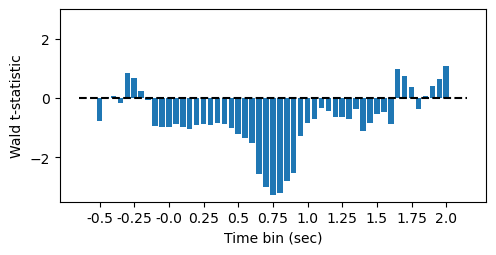

In [37]:
from mne.stats import fdr_correction

zvals = np.array(zvals)

# Plot barplot results
plt.figure(figsize=(5.5, 2.5)); ax=plt.subplot(111)
plt.bar(np.arange(len(zvals)), zvals)
plt.xticks(np.arange(len(zvals))[::5], np.round(time_starts[::5], 3));
plt.ylim(-3.5, 3.0)
plt.hlines([0], xmin=ax.get_xlim()[0], xmax=ax.get_xlim()[1], linestyle='--', color='k')
plt.xlabel('Time bin (sec)'); plt.ylabel('Wald t-statistic')
#plt.savefig('./figs/LMM_tstat_over_time_outnetwork.pdf')

# Run FDR correction (excluding pre-stimulation timebins from this test as no modulation is expected in that window)
pvals_c = np.array(pvals)[np.isfinite(pvals)]
time_starts_c = time_starts[np.isfinite(pvals)]
b, p = fdr_correction(pvals_c[10:], 0.05)

**Plot average power traces pre/post iTBS**

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import sem
import statsmodels.formula.api as smf

def plot_power_timecourse(df, win_centers, title_suffix="", average_within_subjects=True, fname=None, stat_window=None):
    """
    Extracts and plots multi-panel timecourses for global averages and deltas.
    """
    # ----------------------------------------------------
    # PATH A: Average Within Subjects First (Independent N)
    # ----------------------------------------------------
    if average_within_subjects:
        subject_pre = {}
        subject_post = {}
        subject_tstat = {}
        
        for idx, row in df.iterrows():
            sub_id = row['subject']
            pre_epochs = row['pre_tfr']
            post_epochs = row['post_tfr']
            tstat_arr = row.get('t_stats', None)
            
            if pre_epochs is None or post_epochs is None:
                continue
                
            pre_tc = np.nanmean(pre_epochs, axis=0)
            post_tc = np.nanmean(post_epochs, axis=0)
            
            if sub_id not in subject_pre:
                subject_pre[sub_id] = []
                subject_post[sub_id] = []
            subject_pre[sub_id].append(pre_tc)
            subject_post[sub_id].append(post_tc)
            
            if tstat_arr is not None:
                if sub_id not in subject_tstat:
                    subject_tstat[sub_id] = []
                tstat_tc = np.nanmean(tstat_arr, axis=0) if tstat_arr.ndim > 1 else tstat_arr
                subject_tstat[sub_id].append(tstat_tc)

        # Collapse lists to subject-averaged arrays
        pre_arr = np.array([np.nanmean(tc_list, axis=0) for tc_list in subject_pre.values()])
        post_arr = np.array([np.nanmean(tc_list, axis=0) for tc_list in subject_post.values()])
        tstat_arr_all = np.array([np.nanmean(t_list, axis=0) for t_list in subject_tstat.values() if len(t_list) > 0])

    # ----------------------------------------------------
    # PATH B: Flat Pooling (Electrode/Row Level Averaging)
    # ----------------------------------------------------
    else:
        pre_list, post_list, tstat_list = [], [], []
        
        for idx, row in df.iterrows():
            pre_epochs = row['pre_tfr']
            post_epochs = row['post_tfr']
            tstat_arr = row.get('t_stats', None)
            
            if pre_epochs is None or post_epochs is None:
                continue
                
            pre_tc = np.nanmean(pre_epochs, axis=0)
            post_tc = np.nanmean(post_epochs, axis=0)
            
            pre_list.append(pre_tc)
            post_list.append(post_tc)
            
            if tstat_arr is not None:
                tstat_tc = np.nanmean(tstat_arr, axis=0) if tstat_arr.ndim > 1 else tstat_arr
                tstat_list.append(tstat_tc)
                
        pre_arr = np.array(pre_list)
        post_arr = np.array(post_list)
        tstat_arr_all = np.array(tstat_list)

    # 2. Main Array Validation
    if len(pre_arr) == 0:
        print("No valid data found matching the criteria.")
        return

    # Calculate global statistical vectors
    mean_pre = np.nanmean(pre_arr, axis=0)
    sem_pre = sem(pre_arr, axis=0, nan_policy='omit')
    
    mean_post = np.nanmean(post_arr, axis=0)
    sem_post = sem(post_arr, axis=0, nan_policy='omit')
    
    diff_arr = post_arr - pre_arr
    mean_diff = np.nanmean(diff_arr, axis=0)
    sem_diff = sem(diff_arr, axis=0, nan_policy='omit')
    
    has_tstats = len(tstat_arr_all) > 0
    if has_tstats:
        mean_tstat = np.nanmean(tstat_arr_all, axis=0)
        sem_tstat = sem(tstat_arr_all, axis=0, nan_policy='omit')
    
    # Update title dynamically to reflect the toggle state
    mode_str = " (Subject-Averaged)" if average_within_subjects else " (Electrode-Pooled)"
    full_title = f"{title_suffix}{mode_str}"

    # 3. Setting up Stacked Layout (Reduced to 3 panels)
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(8, 7), 
        sharex=True, 
        gridspec_kw={'height_ratios': [2.25, 1, 1], 'hspace': 0.12}
    )
    
    # --- PANEL 1: Grand Average Pre vs Post ---
    ax1.plot(win_centers, mean_pre, color='darkgray', linewidth=2.5, label='Pre-iTBS', linestyle='-')
    ax1.fill_between(win_centers, mean_pre - sem_pre, mean_pre + sem_pre, color='darkgray', alpha=0.2)
    
    ax1.plot(win_centers, mean_post, color='darkred', linewidth=2.5, label='Post-iTBS', linestyle='-')
    ax1.fill_between(win_centers, mean_post - sem_post, mean_post + sem_post, color='darkred', alpha=0.2)
    
    ax1.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.3)
    ax1.axvline(0, color='black', linestyle='-.', linewidth=1, alpha=0.7)
    ax1.set_title(f"Timecourse Power Envelope {full_title}", fontweight='bold', pad=12)
    ax1.set_ylabel('Power (dB)')
    ax1.legend(loc='upper right')
    sns.despine(ax=ax1, bottom=True)
    ax1.tick_params(bottom=False)
    ax1.set_ylim(-0.05, 0.75)
    
    # --- PANEL 2: Combined Delta (Power) ---
    ax2.plot(win_centers, mean_diff, color='black', linewidth=1.75, label='Post - Pre', linestyle='-')
    ax2.fill_between(win_centers, mean_diff - sem_diff, mean_diff + sem_diff, color='black', alpha=0.15)
    ax2.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax2.axvline(0, color='black', linestyle='-.', linewidth=1, alpha=0.7)
    ax2.set_ylabel('Global\n' + r'$\Delta$ Power')
    sns.despine(ax=ax2, bottom=True)
    ax2.tick_params(bottom=False)
    ax2.set_ylim(-0.05, 0.05)
    ax2.set_xlim(-0.5, 2.0)

    # --- PANEL 3: Grand Average T-Stats ---
    if has_tstats:
        ax3.plot(win_centers, mean_tstat, color='navy', linewidth=1.75, label='t-statistic')
        ax3.fill_between(win_centers, mean_tstat - sem_tstat, mean_tstat + sem_tstat, color='navy', alpha=0.15)
    else:
        ax3.text(0.5, 0.5, 'No t_stats data available', transform=ax3.transAxes, ha='center', va='center')

    ax3.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax3.axvline(0, color='black', linestyle='-.', linewidth=1, alpha=0.7)
    ax3.set_ylabel('Grand Avg\n' + r'$t$-statistic')
    ax3.set_xlabel('Time (s)')
    ax3.set_xlim(-0.5, 2.0)
    sns.despine(ax=ax3)
    
    plt.tight_layout()
    if fname:
        plt.savefig(fname)
    plt.show()


def plot_block_statistics(df, win_centers, title_suffix="", average_within_subjects=True, fname=None, stat_window=None):
    """
    Extracts and plots block-wise power deltas and block-wise t-statistics.
    """
    blocks_of_interest = ['iTBS1', 'iTBS2', 'iTBS3']
    
    # ----------------------------------------------------
    # PATH A: Average Within Subjects First (Independent N)
    # ----------------------------------------------------
    if average_within_subjects:
        block_subject_deltas = {b: {} for b in blocks_of_interest}
        block_subject_tstats = {b: {} for b in blocks_of_interest}
        
        for idx, row in df.iterrows():
            sub_id = row['subject']
            row_block = row['block'] if 'block' in df.columns else None
            pre_epochs = row['pre_tfr']
            post_epochs = row['post_tfr']
            tstat_arr = row.get('t_stats', None)
            
            if pre_epochs is None or post_epochs is None:
                continue
                
            pre_tc = np.nanmean(pre_epochs, axis=0)
            post_tc = np.nanmean(post_epochs, axis=0)
            delta_tc = post_tc - pre_tc
            
            if row_block in block_subject_deltas:
                # Track power delta
                if sub_id not in block_subject_deltas[row_block]:
                    block_subject_deltas[row_block][sub_id] = []
                block_subject_deltas[row_block][sub_id].append(delta_tc)
                
                # Track block-level t-statistics
                if tstat_arr is not None:
                    if sub_id not in block_subject_tstats[row_block]:
                        block_subject_tstats[row_block][sub_id] = []
                    tstat_tc = np.nanmean(tstat_arr, axis=0) if tstat_arr.ndim > 1 else tstat_arr
                    block_subject_tstats[row_block][sub_id].append(tstat_tc)

        # Structure block data
        processed_blocks = {}
        processed_blocks_tstats = {}
        for b in blocks_of_interest:
            # Power Delta
            b_subject_avgs = [np.nanmean(tc_list, axis=0) for tc_list in block_subject_deltas[b].values() if len(tc_list) > 0]
            if len(b_subject_avgs) > 0:
                processed_blocks[b] = np.array(b_subject_avgs)
                
            # Block T-Stats
            b_subject_tstats_avgs = [np.nanmean(tc_list, axis=0) for tc_list in block_subject_tstats[b].values() if len(tc_list) > 0]
            if len(b_subject_tstats_avgs) > 0:
                processed_blocks_tstats[b] = np.array(b_subject_tstats_avgs)

    # ----------------------------------------------------
    # PATH B: Flat Pooling (Electrode/Row Level Averaging)
    # ----------------------------------------------------
    else:
        processed_blocks = {b: [] for b in blocks_of_interest}
        processed_blocks_tstats = {b: [] for b in blocks_of_interest}
        
        for idx, row in df.iterrows():
            row_block = row['block'] if 'block' in df.columns else None
            pre_epochs = row['pre_tfr']
            post_epochs = row['post_tfr']
            tstat_arr = row.get('t_stats', None)
            
            if pre_epochs is None or post_epochs is None:
                continue
                
            pre_tc = np.nanmean(pre_epochs, axis=0)
            post_tc = np.nanmean(post_epochs, axis=0)
            
            if row_block in processed_blocks:
                processed_blocks[row_block].append(post_tc - pre_tc)
                if tstat_arr is not None:
                    tstat_tc = np.nanmean(tstat_arr, axis=0) if tstat_arr.ndim > 1 else tstat_arr
                    processed_blocks_tstats[row_block].append(tstat_tc)
                
        # Convert block lists directly to arrays
        processed_blocks = {b: np.array(curves) for b, curves in processed_blocks.items() if len(curves) > 0}
        processed_blocks_tstats = {b: np.array(curves) for b, curves in processed_blocks_tstats.items() if len(curves) > 0}

    # Setting up Stacked Layout (2 panels)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(8, 6), 
        sharex=True, 
        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.12}
    )
    
    mode_str = " (Subject-Averaged)" if average_within_subjects else " (Electrode-Pooled)"
    full_title = f"{title_suffix}{mode_str}"
    ax1.set_title(f"Block Statistics {full_title}", fontweight='bold', pad=12)
    
    colors = sns.color_palette("inferno", n_colors=len(blocks_of_interest))
    block_colors = {b: colors[i] for i, b in enumerate(blocks_of_interest)}
    b_map = {'iTBS1': 1, 'iTBS2': 2, 'iTBS3': 3}
    
    # --- PANEL 1: Block-wise Deltas (Power) & Stats ---
    for b in blocks_of_interest:
        if b in processed_blocks:
            b_arr = processed_blocks[b]
            b_mean = np.nanmean(b_arr, axis=0)
            b_sem = sem(b_arr, axis=0, nan_policy='omit')
            
            ax1.plot(win_centers, b_mean, color=block_colors[b], linewidth=1.75, label=b)
            ax1.fill_between(win_centers, b_mean - b_sem, b_mean + b_sem, color=block_colors[b], alpha=0.12)

    if stat_window is not None:
        t_mask = (win_centers >= stat_window[0]) & (win_centers <= stat_window[1])
        stat_rows_pow = []
        
        if average_within_subjects:
            for b in blocks_of_interest:
                for sub_id, tc_list in block_subject_deltas[b].items():
                    if len(tc_list) > 0:
                        sub_mean_curve = np.nanmean(tc_list, axis=0)
                        val = np.nanmean(sub_mean_curve[t_mask])
                        stat_rows_pow.append({'subject': sub_id, 'block_num': b_map[b], 'delta_power': val})
            df_stat_pow = pd.DataFrame(stat_rows_pow)
            
            if not df_stat_pow.empty and df_stat_pow['subject'].nunique() > 1:
                try:
                    md_pow = smf.mixedlm("delta_power ~ block_num", df_stat_pow, groups=df_stat_pow["subject"])
                    mdf_pow = md_pow.fit()
                    pval_pow = mdf_pow.pvalues['block_num']
                    print("=== Delta Power Model ===")
                    print(mdf_pow.summary())
                    stat_text_pow = f"LMM (Linear Trend): p = {pval_pow:.3f}"
                except Exception:
                    stat_text_pow = "LMM Fit Failed"
        else:
            for b in blocks_of_interest:
                if b in processed_blocks:
                    b_arr = processed_blocks[b]
                    vals = np.nanmean(b_arr[:, t_mask], axis=1)
                    for val in vals:
                        stat_rows_pow.append({'block_num': b_map[b], 'delta_power': val})
            df_stat_pow = pd.DataFrame(stat_rows_pow)
            
            if not df_stat_pow.empty:
                try:
                    md_pow = smf.ols("delta_power ~ block_num", data=df_stat_pow)
                    mdf_pow = md_pow.fit()
                    pval_pow = mdf_pow.pvalues['block_num']
                    stat_text_pow = f"OLS (Linear Trend): p = {pval_pow:.3f}"
                except Exception:
                    stat_text_pow = "OLS Fit Failed"
                    
        ax1.axvspan(stat_window[0], stat_window[1], color='gold', alpha=0.15, zorder=0)
        if 'stat_text_pow' in locals():
            ax1.text(0.02, 0.95, stat_text_pow, transform=ax1.transAxes, 
                     fontsize=9, verticalalignment='top', 
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray'))

    ax1.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax1.axvline(0, color='black', linestyle='-.', linewidth=1, alpha=0.7)
    ax1.set_ylabel('Block\n' + r'$\Delta$ Power')
    ax1.legend(loc='upper right', fontsize=8, frameon=False)
    sns.despine(ax=ax1, bottom=True)
    ax1.tick_params(bottom=False)

    # --- PANEL 2: Block-wise T-Stats & Stats ---
    for b in blocks_of_interest:
        if b in processed_blocks_tstats:
            b_arr_t = processed_blocks_tstats[b]
            b_mean_t = np.nanmean(b_arr_t, axis=0)
            b_sem_t = sem(b_arr_t, axis=0, nan_policy='omit')
            
            ax2.plot(win_centers, b_mean_t, color=block_colors[b], linewidth=1.75, label=b)
            ax2.fill_between(win_centers, b_mean_t - b_sem_t, b_mean_t + b_sem_t, color=block_colors[b], alpha=0.12)

    if stat_window is not None:
        t_mask = (win_centers >= stat_window[0]) & (win_centers <= stat_window[1])
        stat_rows_tstat = []
        
        if average_within_subjects:
            for b in blocks_of_interest:
                for sub_id, tc_list in block_subject_tstats[b].items():
                    if len(tc_list) > 0:
                        sub_mean_curve_t = np.nanmean(tc_list, axis=0)
                        val_t = np.nanmean(sub_mean_curve_t[t_mask])
                        stat_rows_tstat.append({'subject': sub_id, 'block_num': b_map[b], 't_stat_val': val_t})
            df_stat_tstat = pd.DataFrame(stat_rows_tstat)
            
            if not df_stat_tstat.empty and df_stat_tstat['subject'].nunique() > 1:
                try:
                    md_t = smf.mixedlm("t_stat_val ~ block_num", df_stat_tstat, groups=df_stat_tstat["subject"])
                    mdf_t = md_t.fit()
                    pval_t = mdf_t.pvalues['block_num']
                    print("\n=== Block T-Stat Model ===")
                    print(mdf_t.summary())
                    stat_text_tstat = f"LMM (Linear Trend): p = {pval_t:.3f}"
                except Exception:
                    stat_text_tstat = "LMM Fit Failed"
        else:
            for b in blocks_of_interest:
                if b in processed_blocks_tstats:
                    b_arr_t = processed_blocks_tstats[b]
                    vals_t = np.nanmean(b_arr_t[:, t_mask], axis=1)
                    for val_t in vals_t:
                        stat_rows_tstat.append({'block_num': b_map[b], 't_stat_val': val_t})
            df_stat_tstat = pd.DataFrame(stat_rows_tstat)
            
            if not df_stat_tstat.empty:
                try:
                    md_t = smf.ols("t_stat_val ~ block_num", data=df_stat_tstat)
                    mdf_t = md_t.fit()
                    pval_t = mdf_t.pvalues['block_num']
                    stat_text_tstat = f"OLS (Linear Trend): p = {pval_t:.3f}"
                except Exception:
                    stat_text_tstat = "OLS Fit Failed"
                    
        ax2.axvspan(stat_window[0], stat_window[1], color='gold', alpha=0.15, zorder=0)
        if 'stat_text_tstat' in locals():
            ax2.text(0.02, 0.95, stat_text_tstat, transform=ax2.transAxes, 
                     fontsize=9, verticalalignment='top', 
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='lightgray'))

    ax2.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax2.axvline(0, color='black', linestyle='-.', linewidth=1, alpha=0.7)
    ax2.set_ylabel('Block\n' + r'$t$-statistic')
    ax2.set_xlabel('Time (s)')
    ax2.set_xlim(-0.5, 2.0)
    ax2.legend(loc='upper right', fontsize=8, frameon=False)
    sns.despine(ax=ax2)
    
    plt.tight_layout()
    if fname:
        plt.savefig(fname)
    plt.show()

/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/190361032.py:150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


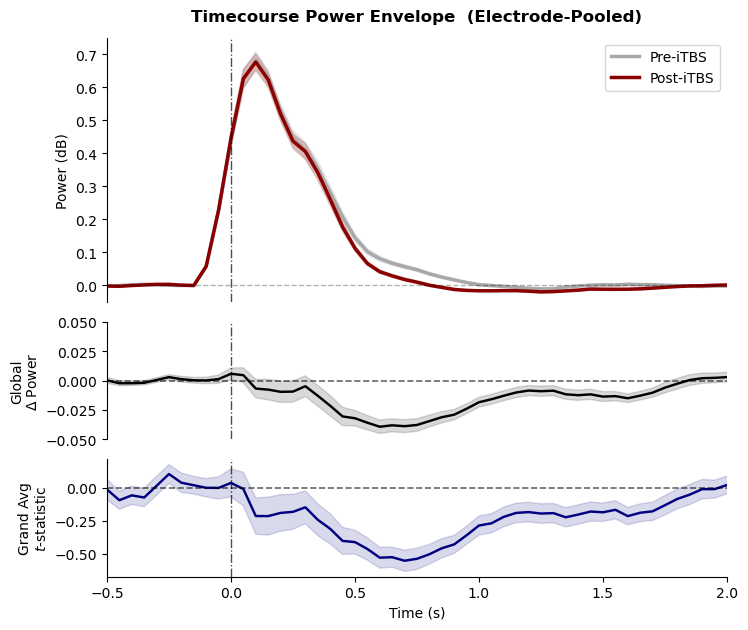

/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/esolomon/anaconda3/envs/mne_development_2025/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/var/folders/t9/sw90nfxj4g1_t03th1dmljd40000gp/T/ipykernel_32101/190361032.py:383: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


=== Delta Power Model ===
          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_power
No. Observations: 30      Method:             REML       
No. Groups:       12      Scale:              0.0023     
Min. group size:  1       Log-Likelihood:     42.0792    
Max. group size:  3       Converged:          Yes        
Mean group size:  2.5                                    
----------------------------------------------------------
           Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.012     0.022   0.551  0.581  -0.031   0.055
block_num  -0.018     0.011  -1.677  0.094  -0.038   0.003
Group Var   0.000     0.009                               


=== Block T-Stat Model ===
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: t_stat_val
No. Observations: 30      Method:             REML      
No. Groups:       12      Scale:  

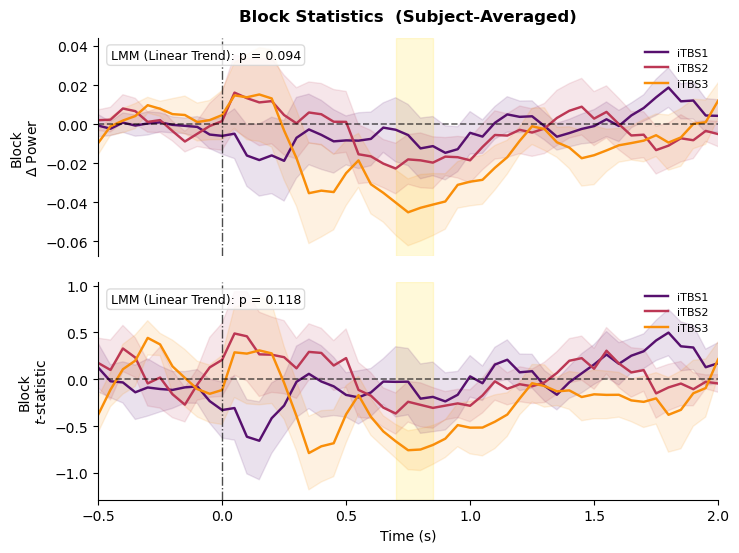

In [48]:
plot_subset = df_joint[
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['block'].str.contains('')) &
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['baseline_ptp']>10) &
                        (df_joint['activeVsSham'].str.contains('active'))
                            ]

# Plot overall power timecourses (using channel-level averaging to make the difference easier to visualize)
plot_power_timecourse(plot_subset, win_centers=win_centers, average_within_subjects=False, 
                     fname=None, stat_window=(0.7, 0.85))

# Plot power timecourses for each individual block and test for linear progression
plot_block_statistics(plot_subset, win_centers=win_centers, fname=None, stat_window=(0.7, 0.85))

### Correlations between PTP and TBS-evoked change at the electrode level
Using a more liberal threshold for channel inclusion to capture high/low variability. Supplement addresses persistence of this effect across thresholds. Note that Pearson estimate included in the plot is not used for formal result in the manuscript (see later code for corresponding mixed effects test).

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_combined_correlations(df, win_centers, time_window, fname=None):
    # 1. Data Prep
    df = df.copy()
    t_start, t_end = time_window
    t_mask = (win_centers >= t_start) & (win_centers <= t_end)
    
    # Calculate your mean window values
    df['mean_window_t'] = [np.nanmean(ts[t_mask]) for ts in df['t_stats'].values]
    
    # --- NEW: Average across blocks per electrode (channel) ---
    # Group by subject and channel to average 'mean_window_t' and 'baseline_ptp'
    # This leaves one unique row per channel per subject.
    df = df.groupby(['subject', 'channel'], as_index=False)[['mean_window_t', 'baseline_ptp']].mean()
    
    # Drop rows with NaNs in the variables we want to correlate
    clean_df = df.dropna(subset=['mean_window_t', 'baseline_ptp'])
    
    if len(clean_df) <= 2:
        print("Insufficient global data to plot.")
        return

    # Calculate overall global statistics
    r, p = pearsonr(clean_df['mean_window_t'], clean_df['baseline_ptp'])
    
    # 2. Setup Figure with GridSpec for Marginal Density Plots
    fig = plt.figure(figsize=(7.5, 5.5))
    gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                          wspace=0.05, hspace=0.05)
    
    ax_top = fig.add_subplot(gs[0, 0])
    ax_right = fig.add_subplot(gs[1, 1])
    ax = fig.add_subplot(gs[1, 0], sharex=ax_top, sharey=ax_right)
    
    # 3. Plot individual subject points using hue to separate them visually
    sns.scatterplot(
        data=clean_df, 
        x='mean_window_t', 
        y='baseline_ptp', 
        hue='subject', 
        palette='husl', 
        alpha=0.6, 
        s=15, 
        ax=ax
    )
    
    # 4. Overlay ONE global trendline across all combined data
    sns.regplot(
        data=clean_df, 
        x='mean_window_t', 
        y='baseline_ptp', 
        ax=ax, 
        scatter=False,  # Don't duplicate the dots
        color='black', 
        line_kws={'linestyle': '--', 'linewidth': 2}
    )
    
    # 5. Plot Aggregate Marginal Densities (KDE)
    sns.kdeplot(
        data=clean_df, 
        x='mean_window_t', 
        ax=ax_top, 
        color='black', 
        fill=True, 
        alpha=0.15, 
        linewidth=1.5
    )
    sns.kdeplot(
        data=clean_df, 
        y='baseline_ptp', 
        ax=ax_right, 
        color='black', 
        fill=True, 
        alpha=0.15, 
        linewidth=1.5
    )
    
    # 6. Annotate and style main axis
    ax.text(
        0.05, 0.92, 
        f'Global Stats:\nr = {r:.2f}\np = {p:.3f}', 
        transform=ax.transAxes, 
        fontsize=10, 
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, boxstyle='round,pad=0.5')
    )
    
    # Safely extract legend details from main axis and anchor outside the right KDE axis
    handles, labels = ax.get_legend_handles_labels()
    ax.get_legend().remove()  # Remove standard overlay legend
    ax_right.legend(handles, labels, title='Subject', bbox_to_anchor=(1.15, 1), loc='upper left')
    
    ax.set_xlabel(f'Pre/Post HFA change (t-stat) [{t_start}-{t_end}s]', fontsize=12)
    ax.set_ylabel('PTP Amplitude (z-score)', fontsize=12)
    
    # Place main title above the top density subplot
    ax_top.set_title('Global Correlation: Combined T-Stat vs. PTP', fontsize=14, fontweight='bold', pad=15)
    
    # Clean up marginal axes styling (remove background lines/spines/labels/ticks)
    for marg_ax in [ax_top, ax_right]:
        marg_ax.set_xlabel('')
        marg_ax.set_ylabel('')
        marg_ax.tick_params(axis='both', which='both', bottom=False, top=False, 
                            left=False, right=False, labelbottom=False, labelleft=False)
        for spine in marg_ax.spines.values():
            spine.set_visible(False)

    #plt.xlim(-3.3, 3.2); plt.ylim(0.32, 1.8)
            
    # Explicitly balance subplot spacing boundaries
    plt.subplots_adjust(left=0.12, right=0.82, bottom=0.12, top=0.88)
    
    if fname:
        plt.savefig(fname, bbox_inches='tight')
    plt.show()

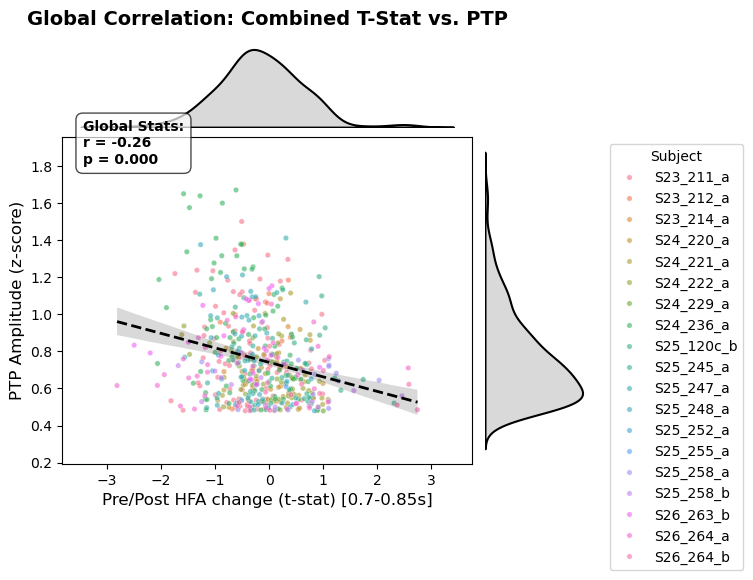

In [52]:
# Note the z-score of 3 threshold used here
plot_subset = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['block'].str.contains('')) & 
                        (df_joint['activeVsSham']=='active') & 
                        (df_joint['baseline_ptp']>3) 
                            ]

# Log-transform the CCEP amplitudes to normalize the distribution
plot_subset_copy = plot_subset.copy()
plot_subset_copy['baseline_ptp'] = np.log10(plot_subset_copy['baseline_ptp'])

# Plot results
plot_combined_correlations(plot_subset_copy, win_centers, time_window=(0.7, 0.85), fname=None)

#### Break down by visualizing effect per subject (displayed in Supplement)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def plot_subject_correlations(df, win_centers, time_window, fname=None):
    # 1. Data Prep
    df = df.copy()
    t_start, t_end = time_window
    t_mask = (win_centers >= t_start) & (win_centers <= t_end)
    
    # Calculate the window mean for each row
    df['mean_window_t'] = [np.nanmean(ts[t_mask]) for ts in df['t_stats'].values]

    # --- NEW: Average across blocks per electrode (channel) ---
    # Group by subject and channel to average 'mean_window_t' and 'baseline_ptp'
    # This leaves one unique row per channel per subject.
    df = df.groupby(['subject', 'channel'], as_index=False)[['mean_window_t', 'baseline_ptp']].mean()

    cols_per_row = 4
    subjects = sorted(df['subject'].unique())
    n_subs = len(subjects)
    n_rows = (n_subs + cols_per_row - 1) // cols_per_row
    
    # 2. Setup Figure (Using GridSpec for subgridspec operations)
    fig = plt.figure(figsize=(4.5 * cols_per_row, 5 * n_rows))
    outer_gs = fig.add_gridspec(n_rows, cols_per_row, hspace=0.4, wspace=0.4)
    
    palette = sns.color_palette("husl", n_subs)
    
    # 3. Iterate through Subjects
    for i, sub in enumerate(subjects):
        # Determine cell position in the outer grid
        r_idx = i // cols_per_row
        c_idx = i % cols_per_row
        
        # Split this specific grid cell: 
        # Row ratios: top marginal (1) to main plot (4)
        # Col ratios: main plot (4) to right marginal (1)
        inner_gs = outer_gs[r_idx, c_idx].subgridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                                                       wspace=0.05, hspace=0.05)
        
        # Create the sub-axes
        ax_top = fig.add_subplot(inner_gs[0, 0])
        ax_right = fig.add_subplot(inner_gs[1, 1])
        ax = fig.add_subplot(inner_gs[1, 0], sharex=ax_top, sharey=ax_right)
        
        sub_df = df[df['subject'] == sub].dropna(subset=['mean_window_t', 'baseline_ptp'])
        
        if len(sub_df) > 2:
            # Calculate stats
            r, p = pearsonr(sub_df['mean_window_t'], sub_df['baseline_ptp'])
            
            # Main Regression Plot
            sns.regplot(data=sub_df, x='mean_window_t', y='baseline_ptp', 
                        ax=ax, color=palette[i], scatter_kws={'alpha':0.6},
                        line_kws={'color': 'black', 'linestyle': '--', 'linewidth': 1})
            
            # --- Marginal Density Plots (KDE) ---
            # Top X-axis Density
            sns.kdeplot(data=sub_df, x='mean_window_t', ax=ax_top, color=palette[i], 
                        fill=True, alpha=0.2, linewidth=1.5)
            # Right Y-axis Density (Note: vertical=True or y='baseline_ptp')
            sns.kdeplot(data=sub_df, y='baseline_ptp', ax=ax_right, color=palette[i], 
                        fill=True, alpha=0.2, linewidth=1.5)
            
            # Annotate Subplot
            ax_top.set_title(f'Sub: {sub}', fontweight='bold', pad=8)
            ax.text(0.05, 0.85, f'r={r:.2f}\np={p:.3f}', transform=ax.transAxes, 
                    fontsize=9, bbox=dict(facecolor='white', alpha=0.5))
            ax.set_xlabel('Pre/Post HFA change (t-stat)')
        else:
            ax.text(0.5, 0.5, 'Insufficient Data', ha='center', va='center')
            ax_top.set_title(f'Sub: {sub} (N={len(sub_df)})')
            
        # Clean up marginal axes styling (remove background lines/spines/labels)
        for marg_ax in [ax_top, ax_right]:
            marg_ax.set_xlabel('')
            marg_ax.set_ylabel('')
            marg_ax.tick_params(axis='both', which='both', bottom=False, top=False, 
                                left=False, right=False, labelbottom=False, labelleft=False)
            for spine in marg_ax.spines.values():
                spine.set_visible(False)

    # Global Labels
    fig.supxlabel(f'Mean T-Stat ({t_start}-{t_end}s)', fontsize=14, y=0.01)
    fig.supylabel('PTP Amplitude (z-score)', fontsize=14, x=0.01)
    plt.suptitle('Correlation by Subject: T-Stat vs. PTP', fontsize=16, fontweight='bold', y=0.98)
    
    # Using fig.subplots_adjust to safely handle layout with nested gridspecs
    plt.subplots_adjust(left=0.07, right=0.95, bottom=0.08, top=0.90)
    
    if fname:
        plt.savefig(fname, bbox_inches='tight')
    plt.show()

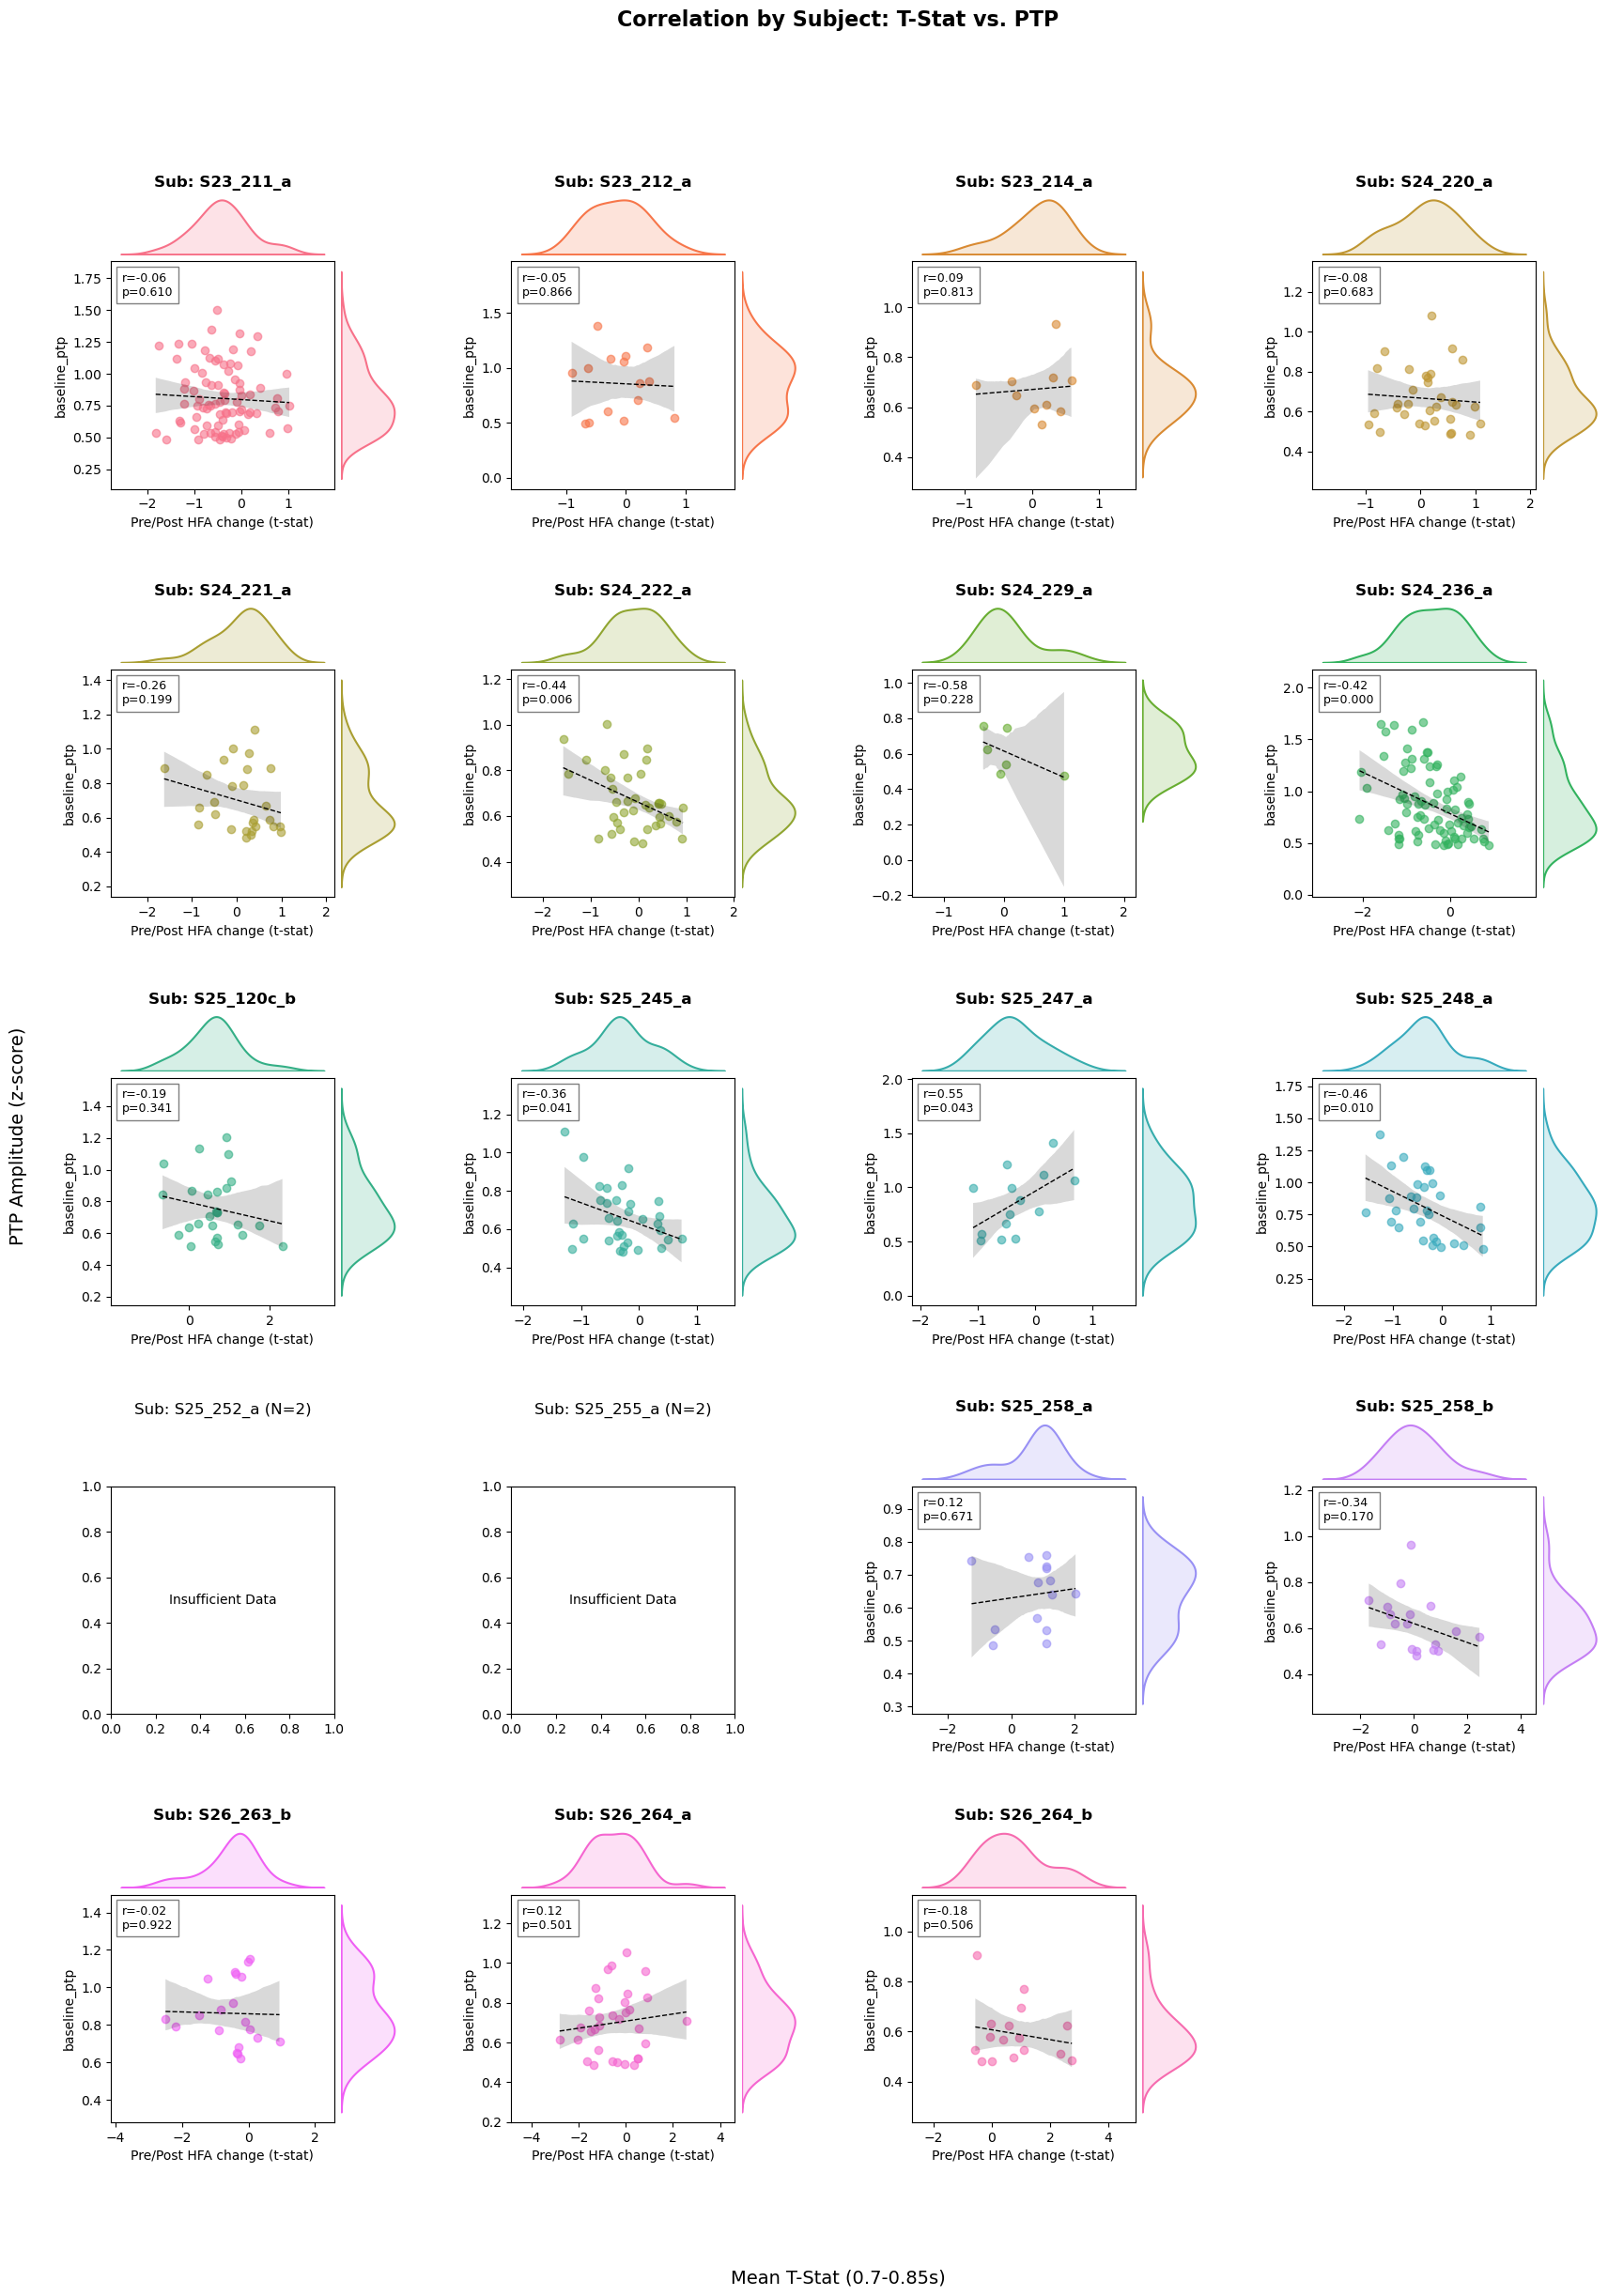

In [54]:
plot_subject_correlations(plot_subset_copy, win_centers, time_window=(0.7, 0.85), fname=None)

#### LME model for assessing PTP vs. t-stat relationship

In [73]:
def run_repeated_measures_lme(df, win_centers, t_start=0.7, t_end=0.85, average_blocks=True,
                              scaling='within', min_electrodes_per_subject=5):
    """
    scaling:
      'within' : (x - subject_mean) / subject_sd   -> purely within-subject effect
      'hybrid' : (x - subject_mean) / pooled_sd    -> same centering, stabler denominator
      'global' : (x - grand_mean)  / grand_sd      -> original behavior (mixes within/between)
    """
    df_lme = df.copy()

    # 1. Prepare predictor (Mean T-stat in window)
    t_mask = (win_centers >= t_start) & (win_centers <= t_end)
    df_lme['mean_window_t'] = [np.nanmean(ts[t_mask]) for ts in df_lme['t_stats'].values]

    has_distance = 'distance' in df_lme.columns

    # --- Toggle to average across blocks ---
    if average_blocks:
        # (Assuming 'distance' is static per electrode pair, taking the mean is safe)
        cols_to_avg = ['mean_window_t', 'baseline_ptp']
        if has_distance:
            cols_to_avg.append('distance')

        # NOTE: an unweighted mean ignores that electrodes with more blocks are measured
        # more precisely. Check whether block counts are roughly balanced.
        df_lme = df_lme.groupby(['subject', 'channel'], as_index=False)[cols_to_avg].mean()

    # 2. Drop subjects too small for a stable per-subject SD
    #    (dividing by a noisy denominator inflates that subject's scores and their leverage)
    if scaling in ('within', 'hybrid'):
        sizes = df_lme.drop_duplicates(['subject', 'channel']).groupby('subject').size()
        too_small = sizes[sizes < min_electrodes_per_subject]
        if len(too_small):
            print(f"[info] dropping subjects with < {min_electrodes_per_subject} electrodes: "
                  f"{dict(too_small)}")
            df_lme = df_lme[df_lme['subject'].isin(sizes[sizes >= min_electrodes_per_subject].index)].copy()

    # 3. Standardize
    def _wz(s):
        sd = s.std()
        # guard against a subject with a single electrode / zero variance
        return (s - s.mean()) / sd if np.isfinite(sd) and sd > 0 else pd.Series(np.nan, index=s.index)

    src_to_dst = {'baseline_ptp': 'ptp_z', 'mean_window_t': 't_stat_z'}
    if has_distance:
        src_to_dst['distance'] = 'distance_z'

    for src, dst in src_to_dst.items():
        if scaling == 'global':
            df_lme[dst] = (df_lme[src] - df_lme[src].mean()) / df_lme[src].std()
        elif scaling == 'within':
            df_lme[dst] = df_lme.groupby('subject')[src].transform(_wz)
        elif scaling == 'hybrid':
            centered = df_lme[src] - df_lme.groupby('subject')[src].transform('mean')
            df_lme[dst] = centered / centered.std()
        else:
            raise ValueError(f"scaling must be 'within', 'hybrid' or 'global'; got {scaling!r}")

    # 4. Unique electrode ID + drop rows the model can't use
    df_lme['sub_chan'] = df_lme['subject'].astype(str) + "_" + df_lme['channel'].astype(str)

    model_cols = ['t_stat_z', 'ptp_z'] + (['distance_z'] if has_distance else [])
    n_before = len(df_lme)
    df_lme = df_lme.dropna(subset=model_cols).copy()
    if len(df_lme) < n_before:
        print(f"[info] dropped {n_before - len(df_lme)} row(s) with NaN in model columns")

    # 5. Fixed-effects formula
    rhs = ['ptp_z'] + (['distance_z'] if has_distance else [])
    if not average_blocks:
        rhs.append('C(block)')   # distance is now kept here too, unlike the original
    formula = "t_stat_z ~ " + " + ".join(rhs)

    # 6. Random effects
    #    With within-subject centering, every subject's outcome mean is exactly 0 by
    #    construction, so a random intercept has nothing to explain and comes back
    #    singular. Drop it and keep the slopes, which are the part doing real work.
    slopes = ['ptp_z'] #+ (['distance_z'] if has_distance else [])
    re_formula = ('0 + ' if scaling in ('within', 'hybrid') else '1 + ') + ' + '.join(slopes)

    # When blocks are NOT averaged there are repeated measures within electrode, so the
    # electrode needs its own variance component.
    vc_formula = None if average_blocks else {"electrode": "0 + C(sub_chan)"}

    model = smf.mixedlm(formula, df_lme,
                        groups=df_lme["subject"],
                        re_formula=re_formula,
                        vc_formula=vc_formula,
                        )

    result = model.fit(reml=True)

    print(f"--- LME Results (scaling={scaling}, averaged blocks={average_blocks}) ---")
    print(result.summary())
    if not result.converged:
        print("[warn] did not converge - try re_formula='0 + ptp_z' (drop the distance slope)")

    if scaling in ('within', 'hybrid'):
        print("\nInterpretation: within-subject association between baseline PTP and the "
              "evoked response"
              + (", controlling for distance." if has_distance else ".")
              + "\nBetween-subject differences are removed by construction.")

    return result, df_lme

In [67]:
# Log-transform the CCEP amplitudes to normalize the distribution
plot_subset = df_joint[ 
                        (~df_joint['jp_channel_1'].astype(str).str.contains(bad_elec_keywords, case=False)) & 
                        (df_joint['subject'].str.contains('')) & 
                        (df_joint['frequency']=='HFA') & 
                        (df_joint['is_bad'] == False) &
                        (df_joint['is_lead'] == False) &
                        (df_joint['block'].str.contains('')) & 
                        (df_joint['activeVsSham']=='active') & 
                        (df_joint['baseline_ptp']>3) 
                            ]

plot_subset_copy = plot_subset.copy()
plot_subset_copy['baseline_ptp'] = np.log10(plot_subset_copy['baseline_ptp'])

# Execution (Toggle True or False as needed)
lme_repeated_results, df_lme = run_repeated_measures_lme(plot_subset_copy, win_centers, average_blocks=True, scaling='hybrid')

[info] dropping subjects with < 5 electrodes: {'S25_252_a': np.int64(2), 'S25_255_a': np.int64(2)}
--- LME Results (scaling=hybrid, averaged blocks=True) ---
              Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    t_stat_z 
No. Observations:     502        Method:                REML     
No. Groups:           17         Scale:                 0.9058   
Min. group size:      6          Log-Likelihood:        -700.7391
Max. group size:      86         Converged:             Yes      
Mean group size:      29.5                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.000    0.042  0.000 1.000 -0.083  0.083
ptp_z                  -0.177    0.072 -2.458 0.014 -0.319 -0.036
distance_z             -0.152    0.078 -1.945 0.052 -0.306  0.00

#### Supplement: Reanalyze CCEP amplitude (PTP) vs. T-stat relationship for varying amplitude thresholds
In the published Supplement, models including random slopes with respect to distance are used whenever model converges, but these slopes are dropped in case of model convergence failure. Neither model converges at a threshold of 8, in which case the effect is approximated with a Pearson correlation. 

--- LME Results (scaling=hybrid, averaged blocks=True) ---
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: t_stat_z  
No. Observations: 3422    Method:             REML      
No. Groups:       26      Scale:              0.9779    
Min. group size:  39      Log-Likelihood:     -4838.5935
Max. group size:  202     Converged:          Yes       
Mean group size:  131.6                                 
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept      0.000    0.017  0.000 1.000 -0.033  0.033
ptp_z         -0.055    0.034 -1.610 0.108 -0.123  0.012
distance_z     0.015    0.019  0.771 0.441 -0.023  0.052
ptp_z Var      0.018    0.008                           


Interpretation: within-subject association between baseline PTP and the evoked response, controlling for distance.
Between-subject differences are remo

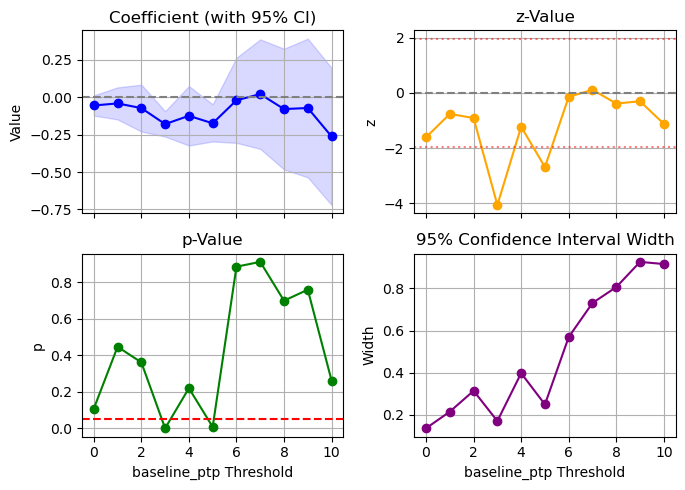

In [74]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats  # Added import for scipy.stats

# 1. Initialize lists to store the results and convergence flags
thresholds = list(range(0, 11))
coefs = []
z_values = []
p_values = []
ci_lowers = []
ci_uppers = []
convergence_warnings = []  # Logs whether a warning occurred at each threshold

# 2. Loop through thresholds
for thresh in thresholds:
    # Filter the dataframe dynamically using the current threshold
    plot_subset = df_joint[
        (~df_joint["jp_channel_1"]
         .astype(str)
         .str.contains(bad_elec_keywords, case=False))
        & (df_joint["subject"].str.contains(""))
        & (df_joint["frequency"] == "HFA")
        & (df_joint["is_bad"] == False)
        & (df_joint["is_lead"] == False)
        & (df_joint["block"].str.contains(""))
        & (df_joint["activeVsSham"] == "active")
        & (df_joint["baseline_ptp"] > thresh)
        & (df_joint["stim_region"].str.contains("", case=False))
    ]

    if len(plot_subset) < 5:
        print(f"Skipping threshold {thresh}: Insufficient data points.")
        for lst in [coefs, z_values, p_values, ci_lowers, ci_uppers]:
            lst.append(np.nan)
        convergence_warnings.append(False)
        continue

    plot_subset_copy = plot_subset.copy()
    plot_subset_copy["baseline_ptp"] = np.log10(
        plot_subset_copy["baseline_ptp"])

    had_warning_this_loop = False

    with warnings.catch_warnings(record=True) as caught_warnings:
        warnings.simplefilter("always")

        try:
            lme_repeated_results, df_lme = run_repeated_measures_lme(
                plot_subset_copy, win_centers, average_blocks=True, scaling='hybrid',
            )

            # Log if any convergence warnings were generated in this loop
            had_warning_this_loop = any(
                "converge" in str(w.message).lower() for w in caught_warnings
            )

            if had_warning_this_loop:
                print(f"Convergence warning at threshold {thresh}. Falling back to Pearson correlation.")
                
                # Drop NaNs to ensure scipy.stats doesn't error out
                valid_data = df_lme[["t_stat_z", "ptp_z"]].dropna()
                n = len(valid_data)
                
                if n > 3:
                    # Calculate r and exact p-value
                    r, p = stats.pearsonr(valid_data["t_stat_z"], valid_data["ptp_z"])
                    
                    # Fisher's z-transformation for 95% CI
                    z = np.arctanh(r)
                    se = 1.0 / np.sqrt(n - 3)
                    z_crit = 1.96  # Approx for 95% CI
                    
                    ci_lower = np.tanh(z - z_crit * se)
                    ci_upper = np.tanh(z + z_crit * se)
                    z_stat = z / se  # Z-score for the correlation test
                    
                    coefs.append(r)
                    p_values.append(p)
                    ci_lowers.append(ci_lower)
                    ci_uppers.append(ci_upper)
                    z_values.append(z_stat)
                else:
                    # Extreme edge case fallback if dropping NaNs leaves <= 3 points
                    corr = df_lme["t_stat_z"].corr(df_lme["ptp_z"])
                    coefs.append(corr)
                    for lst in [z_values, p_values, ci_lowers, ci_uppers]:
                        lst.append(np.nan)
            else:
                # Safely grab parameters from the model's structural attributes
                if "ptp_z" in lme_repeated_results.fe_params:
                    c = lme_repeated_results.fe_params["ptp_z"]
                    coefs.append(c)
    
                    se = lme_repeated_results.bse["ptp_z"]
                    z_values.append(c / se if se != 0 else np.nan)
    
                    p_values.append(lme_repeated_results.pvalues["ptp_z"])
    
                    ci = lme_repeated_results.conf_int().loc["ptp_z"]
                    ci_lowers.append(ci[0])
                    ci_uppers.append(ci[1])
                else:
                    print(
                        f"Warning: 'ptp_z' factor not found at threshold {thresh}"
                    )
                    for lst in [coefs, z_values, p_values, ci_lowers, ci_uppers]:
                        lst.append(np.nan)

        except Exception as e:
            print(f"Model strictly failed/errored at threshold {thresh}: {e}")
            for lst in [coefs, z_values, p_values, ci_lowers, ci_uppers]:
                lst.append(np.nan)

    convergence_warnings.append(had_warning_this_loop)

# 3. Standard Plotting
fig, axs = plt.subplots(2, 2, figsize=(7, 5), sharex=True)

# Top Left: Coefficient with CI bounds
axs[0, 0].plot(thresholds, coefs, color="blue", marker="o", label="Coef")
axs[0, 0].fill_between(
    thresholds,
    np.array(ci_lowers, dtype=float),
    np.array(ci_uppers, dtype=float),
    color="blue",
    alpha=0.15,
    label="95% CI",
)
axs[0, 0].axhline(0, color="gray", linestyle="--")
axs[0, 0].set_title("Coefficient (with 95% CI)")
axs[0, 0].set_ylabel("Value")
axs[0, 0].grid(True)

# Top Right: Z-Value
axs[0, 1].plot(thresholds, z_values, color="orange", marker="o")
axs[0, 1].axhline(0, color="gray", linestyle="--")
axs[0, 1].axhline(1.96, color="red", linestyle=":", alpha=0.5)
axs[0, 1].axhline(-1.96, color="red", linestyle=":", alpha=0.5)
axs[0, 1].set_title("z-Value")
axs[0, 1].set_ylabel("z")
axs[0, 1].grid(True)

# Bottom Left: P-Value
axs[1, 0].plot(thresholds, p_values, color="green", marker="o")
axs[1, 0].axhline(0.05, color="red", linestyle="--", label="p = 0.05")
axs[1, 0].set_title("p-Value")
axs[1, 0].set_xlabel("baseline_ptp Threshold")
axs[1, 0].set_ylabel("p")
axs[1, 0].grid(True)

# Bottom Right: Confidence Interval Width
ci_width = np.array(ci_uppers, dtype=float) - np.array(ci_lowers, dtype=float)
axs[1, 1].plot(thresholds, ci_width, color="purple", marker="o")
axs[1, 1].set_title("95% Confidence Interval Width")
axs[1, 1].set_xlabel("baseline_ptp Threshold")
axs[1, 1].set_ylabel("Width")
axs[1, 1].grid(True)

plt.tight_layout()
#plt.savefig('./figs/supplemental_threshold_correlation_analysis.pdf')
plt.show()